# Limpieza de datos
El conjunto de datos utilizados requiere de una limpieza preliminar debido a las diferentes limitaciones causadas por el uso no ponderado para inteligencias articificiales. Especialmente, se pretende abordar la siguiente limitaciónÑ
- **Imagenes con diferente contenido:** en casi todos los casos, las imagenes originales y sus contrapartes con el recuadro de logo no coinciden en contenido, es decir, si se fuesen a sobreponer una sobre otra, su tamaño no coincide. Esto representa un problema, pues este proyecto se basa en la transfrencia de la posicion especifica del recuadro de logo con la imagen original. 

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import random

In [ ]:
# Conjunto de datos originales
RAW_DIRS = {
    "bottles": Path("./data/raw/bottles"),
    "tshirts":  Path("./data/raw/tshirts"),
}

# Directorio para imagenes limpiadas
CLEAN_DIRS = {
    "bottles": Path("./data/clean/bottles"),
    "tshirts":  Path("./data/clean/tshirts"),
}
# Asegurar creacion de los directorios
for d in CLEAN_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

In [13]:
# Valores para calidad de imagen y samples
JPEG_QUALITY = 95
N_SAMPLES = 2

## 1. Limitaciones del dataset

El problema principal, por tanto, se puede observar en la siguiente figura. El abordaje decidido para manejar esta limitacion fue recortar ambas imagenes, tanto origina como su label, para mostrar solo el contenido. Esto permitiria que ambas sean comprables en terminos de contenido, sin embargo levanta las siguientes consideraciones:
1. **Aspect Ratio y Resolucion**:
    Las imagenes, en caso sean recortadas, aunque introducirian una comparabilidad mas alta, no podemos confirmar que el Aspect Ratio (es decir, la relacion entre altura y anchura) sea igualmente consistente. Asimismo, la resolución de las imagenes se vería comprometida y seria inconsistente entre la imagen origina y su label. 

2. **Sombras impiden recorte**
    Algunas imagenes de botellas contienen sombras y su presencia es inconsistente. El conjunto de datos presenta sombras en imagenes al azar, lo que complica la implementacion de un recorte naive de contenido global entre imagen original e imagen con label. Incluso hay casos donde la original si tiene sombra y la label no y viceversa


In [36]:
examples = {
    "bottles": ["./data/raw/bottles/image-0576.jpg", "./data/raw/bottles/image-0576-labeled.jpg"],
    "tshirts": ["./data/raw/tshirts/image-3707.jpg", "./data/raw/tshirts/image-3707-labeled.jpg"]
}

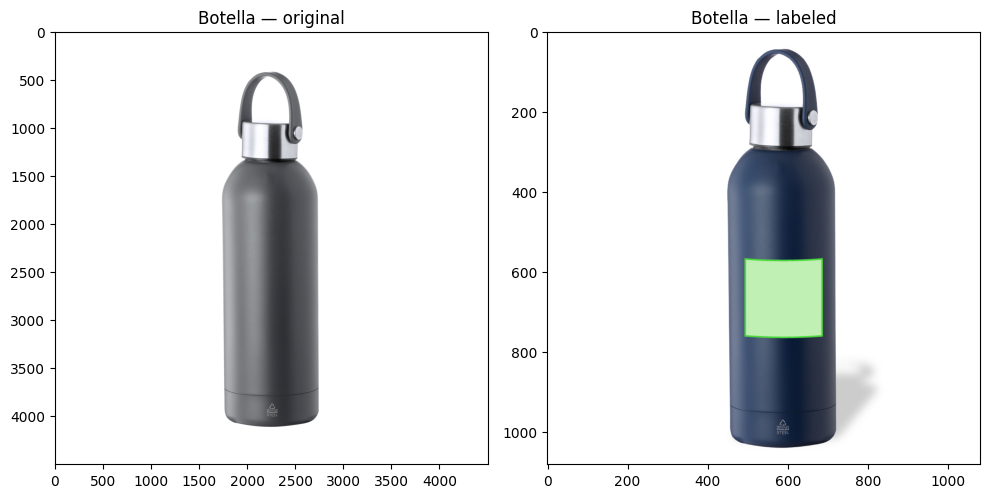

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
orig_rgb  = cv2.cvtColor(cv2.imread(str(examples["bottles"][0])),    cv2.COLOR_BGR2RGB)
label_rgb = cv2.cvtColor(cv2.imread(str(str(examples["bottles"][1]))), cv2.COLOR_BGR2RGB)
axes[0].imshow(orig_rgb)
axes[0].set_title(f"Botella — original")
axes[1].imshow(label_rgb)
axes[1].set_title(f"Botella — labeled")
plt.tight_layout()
plt.show()


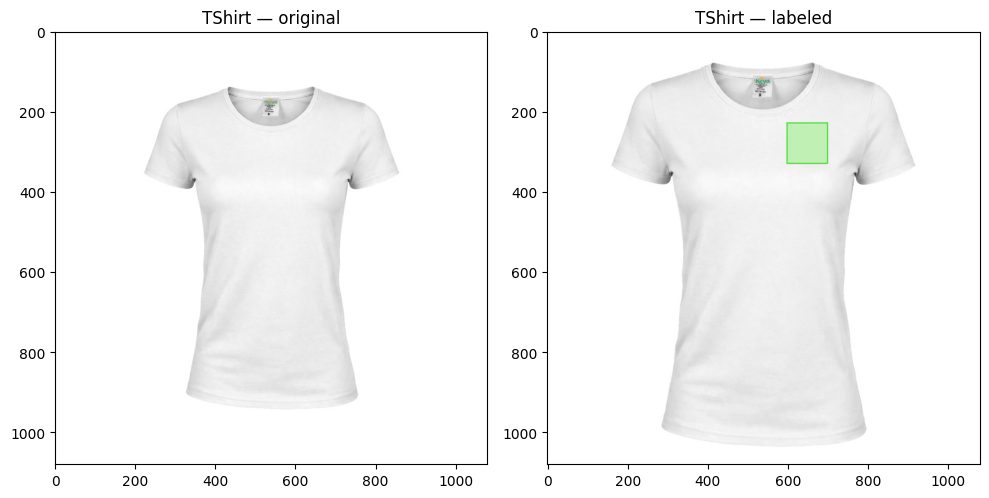

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
orig_rgb  = cv2.cvtColor(cv2.imread(str(examples["tshirts"][0])),    cv2.COLOR_BGR2RGB)
label_rgb = cv2.cvtColor(cv2.imread(str(str(examples["tshirts"][1]))), cv2.COLOR_BGR2RGB)
axes[0].imshow(orig_rgb)
axes[0].set_title(f"TShirt — original")
axes[1].imshow(label_rgb)
axes[1].set_title(f"TShirt — labeled")
plt.tight_layout()
plt.show()


## 2. Solucion aplicada
Se proponen las siguientes soluciones para cada uno de estos problemas
1. **Aspect Ratio y Resolucion - Solución:**
    El contenido mismo de la imagen de label no sera utilizada por el modelo final, lo unico que importa para el procesamiento de datos es el posicionamiento correcto de la imagen de label para que haya consistencia entre ambas. Por tanto, la solucion implica comprometer la resolucion y AR de la imagen de label para asegurar transferencia entre los recortes.
2. **Sombras impiden recorte - Solucion:**
    La solucion se presenta en varias partes, primero, en termino del alcance. Solo las imagenes de botellas presentan sombras, las imagenes de camisas no tienen sombras, y un recorte de contenido Naive es aplicable para ellas.
    Asimismo, las botellas, aunque las sombras sean inconsistenctes en su presencia, no son inconsistente en su forma. Toda las sombras presentes estan en el lado derecho de la imagen, lo que se correlaciona con un lado izquierdo mas brillante. Esto informa la decision ed como aplicar el recorte a partir de umbrales de tolerancia. La solucion aplicada consiste de dos umbrales, uno estricto y otro agresivo dependientes del lado de la imagen donde se apliquen
      - El agresivo se aplica en el area derecho de la imagen, donde las sombras estan presentes. En este caso el recorte de contenido se reduce en probabilidad tambien, pues dado que es el lado oscuro, el contraste entre fondo con sombra y contenido es mayor, lo que no afectaria la viabilidad del recorte.
      - El estricto se aplicaria al lado izquierdo de la imagen, la cual es mas brillante y no presenta sombra.

In [47]:
# Umbral estricto (muy cercano a blanco puro 255)
THRESH_STRICT     = 250

# Umbral agresivo (Acepta mas que el estructo)
THRESH_AGGRESSIVE = 200

# Margen adicional
CROP_MARGIN = 12

## 3. Recorte del Contenido

In [43]:
def get_content_bbox(img_bgr, thresh_strict, thresh_aggressive, margin):
    """
    Regresa (x1, y1, x2, y2)
    Mitades: izquierda + superior = Umbral estricto.
    Derecha + Inferior = umbral estricto
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    # Puntos de corte
    mid_x = w // 2
    mid_y = h // 2
    
    content = np.zeros((h, w), dtype=bool)

    # Umbral estricto
    content[:mid_y, :mid_x] = gray[:mid_y, :mid_x] < thresh_strict
    content[mid_y:, :mid_x] = gray[mid_y:, :mid_x] < thresh_strict
    
    # Umbral agresivo
    content[:mid_y, mid_x:] = gray[:mid_y, mid_x:] < thresh_aggressive
    content[mid_y:, mid_x:] = gray[mid_y:, mid_x:] < thresh_aggressive

    rows = np.any(content, axis=1)
    cols = np.any(content, axis=0)

    # Calculo de limites
    y1 = max(0,   int(np.where(rows)[0][0])  - margin)
    y2 = min(h,   int(np.where(rows)[0][-1]) + margin + 1)
    x1 = max(0,   int(np.where(cols)[0][0])  - margin)
    x2 = min(w,   int(np.where(cols)[0][-1]) + margin + 1)

    return x1, y1, x2, y2


In [15]:
# Estracción de parejas image + image-labeled
pairs = []
for class_name, directory in RAW_DIRS.items():
    all_stems = {f.stem: f for f in directory.glob("*.jpg")}
    originals = {s: p for s, p in all_stems.items() if not s.endswith("-labeled")}
    labeled   = {s.replace("-labeled", ""): p for s, p in all_stems.items() if s.endswith("-labeled")}

    for img_id, orig_path in sorted(originals.items()):
        if img_id in labeled:
            pairs.append({
                "class":      class_name,
                "id":         img_id,
                "orig_path":  orig_path,
                "label_path": labeled[img_id],
            })

print(f"Parejas totales validas: {len(pairs)}")
pd.DataFrame(pairs).groupby("class")["id"].count()

Parejas totales validas: 247


class
bottles    161
tshirts     86
Name: id, dtype: int64

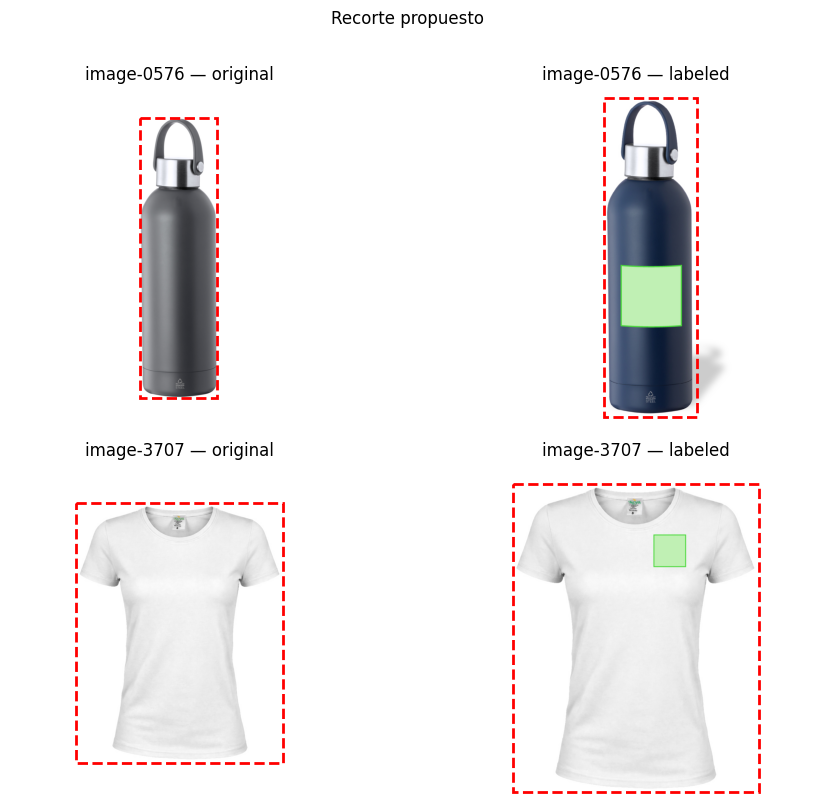

In [ ]:
import random
# Selección de Parejas aleatorias
sample_pairs = [
    {"class": cls, "id": Path(paths[0]).stem, "orig_path": Path(paths[0]), "label_path": Path(paths[1])}
    for cls, paths in examples.items()
]

fig, axes = plt.subplots(len(sample_pairs), 2, figsize=(10, 4 * len(sample_pairs)))
if len(sample_pairs) == 1:
    axes = [axes]

# Showcase de recorte
for i, p in enumerate(sample_pairs):
    orig_bgr  = cv2.imread(str(p["orig_path"]))
    label_bgr = cv2.imread(str(p["label_path"]))

    # Tshirts NO tienen umbral agresivo, pues no tienen sombras.
    t_hi = THRESH_AGGRESSIVE if p["class"] == "bottles" else THRESH_STRICT
    ox1, oy1, ox2, oy2 = get_content_bbox(orig_bgr,  THRESH_STRICT, t_hi, CROP_MARGIN)
    lx1, ly1, lx2, ly2 = get_content_bbox(label_bgr, THRESH_STRICT, t_hi, CROP_MARGIN)

    orig_rgb  = cv2.cvtColor(orig_bgr,  cv2.COLOR_BGR2RGB)
    label_rgb = cv2.cvtColor(label_bgr, cv2.COLOR_BGR2RGB)

    for ax, img, (x1, y1, x2, y2), title in [
        (axes[i][0], orig_rgb,  (ox1, oy1, ox2, oy2), f"{p['id']} — original"),
        (axes[i][1], label_rgb, (lx1, ly1, lx2, ly2), f"{p['id']} — labeled"),
    ]:
        ax.imshow(img)
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="red", facecolor="none", linestyle="--"
        )
        ax.add_patch(rect)
        ax.set_title(title)
        ax.axis("off")

plt.suptitle("Recorte propuesto", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [51]:
# Aplicacion completa
stats = []
for p in pairs:
    orig_bgr  = cv2.imread(str(p["orig_path"]))
    label_bgr = cv2.imread(str(p["label_path"]))

    t_hi = THRESH_AGGRESSIVE if p["class"] == "bottles" else THRESH_STRICT
    ox1, oy1, ox2, oy2 = get_content_bbox(orig_bgr,  THRESH_STRICT, t_hi, CROP_MARGIN)
    lx1, ly1, lx2, ly2 = get_content_bbox(label_bgr, THRESH_STRICT, t_hi, CROP_MARGIN)

    orig_crop  = orig_bgr [oy1:oy2, ox1:ox2]
    label_crop = label_bgr[ly1:ly2, lx1:lx2]

    oh, ow = orig_crop.shape[:2]
    lh, lw = label_crop.shape[:2]

    # Cambiar tamaño de labeled para coinicidir siempre con la original
    # INTER_LINEAR para upscale y downscale aceptables para la extracción de la mascara
    
    if (lw, lh) != (ow, oh):
        label_crop = cv2.resize(label_crop, (ow, oh), interpolation=cv2.INTER_LINEAR)
        
    # Guardar en cleaned
    out_dir   = CLEAN_DIRS[p["class"]]
    orig_out  = out_dir / (p["id"] + ".jpg")
    label_out = out_dir / (p["id"] + "-labeled.jpg")

    cv2.imwrite(str(orig_out),  orig_crop,  [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
    cv2.imwrite(str(label_out), label_crop, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

    stats.append({
        "class":        p["class"],
        "id":           p["id"],
        "orig_raw_w":   orig_bgr.shape[1],  "orig_raw_h":  orig_bgr.shape[0],
        "orig_crop_w":  ow,                 "orig_crop_h": oh,
        "label_resized": (lw, lh) != (ow, oh),
    })

df_stats = pd.DataFrame(stats)
print(f"Recortes Guardados: {len(df_stats)} parejas")
print(f"Cambios de tamaño realizados: {df_stats['label_resized'].sum()} ({df_stats['label_resized'].mean()*100:.1f}%)")


Recortes Guardados: 247 parejas
Cambios de tamaño realizados: 244 (98.8%)


## 5. Estadisticas de reducción

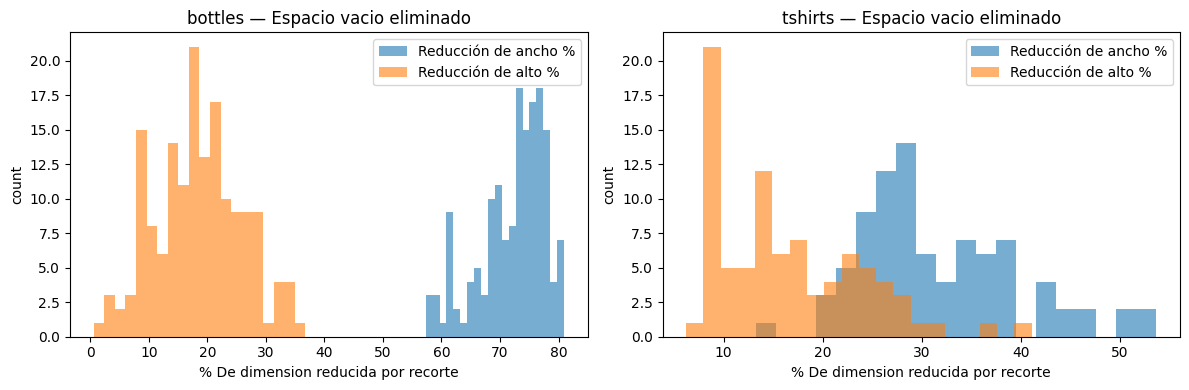

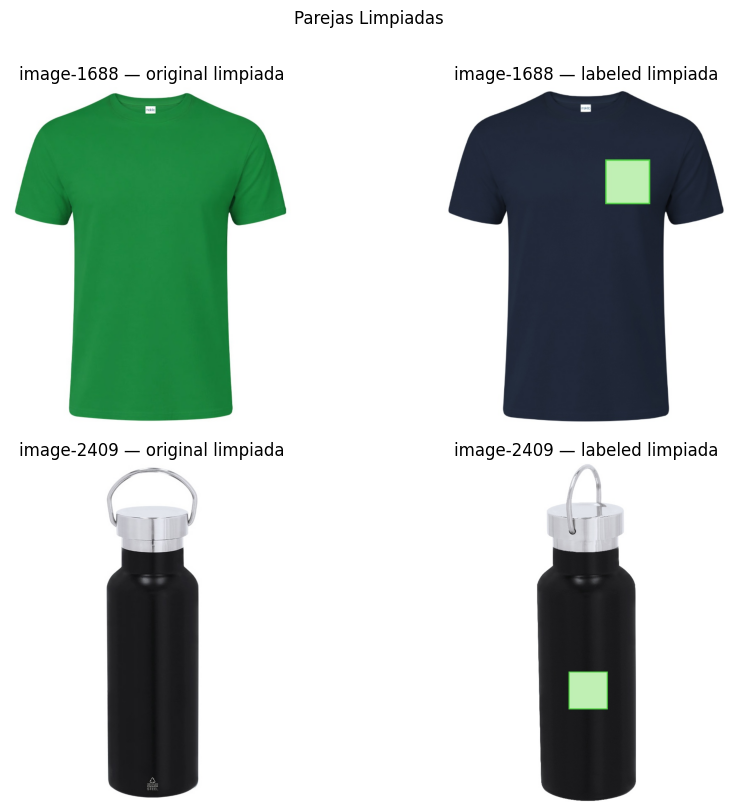

In [56]:
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, class_name in zip(axes, ["bottles", "tshirts"]):
    sub = df_stats[df_stats["class"] == class_name]
    width_reduction  = (sub["orig_raw_w"] - sub["orig_crop_w"]) / sub["orig_raw_w"] * 100
    height_reduction = (sub["orig_raw_h"] - sub["orig_crop_h"]) / sub["orig_raw_h"] * 100
    ax.hist(width_reduction,  bins=20, alpha=0.6, label="Reducción de ancho %")
    ax.hist(height_reduction, bins=20, alpha=0.6, label="Reducción de alto %")
    ax.set_title(f"{class_name} — Espacio vacio eliminado")
    ax.set_xlabel("% De dimension reducida por recorte")
    ax.set_ylabel("count")
    ax.legend()
plt.tight_layout()
plt.show()

# Pareja al azar
clean_sample = random.sample(stats, min(N_SAMPLES, len(stats)))

fig, axes = plt.subplots(len(clean_sample), 2, figsize=(10, 4 * len(clean_sample)))
if len(clean_sample) == 1:
    axes = [axes]

for i, s in enumerate(clean_sample):
    out_dir   = CLEAN_DIRS[s["class"]]
    orig_rgb  = cv2.cvtColor(cv2.imread(str(out_dir / (s["id"] + ".jpg"))),          cv2.COLOR_BGR2RGB)
    label_rgb = cv2.cvtColor(cv2.imread(str(out_dir / (s["id"] + "-labeled.jpg"))),  cv2.COLOR_BGR2RGB)
    axes[i][0].imshow(orig_rgb);  axes[i][0].set_title(f"{s['id']} — original limpiada"); axes[i][0].axis("off")
    axes[i][1].imshow(label_rgb); axes[i][1].set_title(f"{s['id']} — labeled limpiada");  axes[i][1].axis("off")

plt.suptitle("Parejas Limpiadas", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


Las imagenes procesadas estaran presentes en el folder "cleaned" de este directorio para uso en la etapa de proceseamiento